## Healthcare Cost Analysis

### What is Healthcare?

#### Healthcare is a system that focuses on maintaining and improving human health through prevention, diagnosis, and treatment of diseases. It plays a key role in improving life expectancy and overall quality of life.

### Why Healthcare is Important?

#### Healthcare is essential because it helps in early disease detection, reduces medical risks, and supports better health outcomes. It also plays an important role in economic stability by keeping the population healthy and productive.

### How Healthcare Costs Work?

#### Healthcare costs depend on multiple factors such as age, BMI, smoking habits, number of children, region, and overall health condition. These factors influence the final medical insurance charges, which is the main target variable in this dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv('insurance (2).csv')

In [3]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

## Data Review
#### The dataset contains 7 features: age, sex, BMI, children, smoker, region, and charges. Among these, charges is the target variable representing medical insurance cost. The dataset includes both numerical and categorical variables.

## Literature Review

#### Healthcare cost prediction has been widely studied because of its importance in insurance pricing and risk analysis.
#### **Key Findings from Existing Studies:**
#### • Age and smoking are among the strongest predictors of medical costs.
#### • BMI (Body Mass Index) is strongly linked with chronic diseases and higher healthcare expenses.
#### • Regional differences affect insurance charges due to variation in healthcare systems and cost of living.
#### **Important Sources:**
#### • World Health Organization (WHO) – Healthcare systems overview
#### • Centers for Disease Control and Prevention (CDC) – Chronic disease & risk factors
#### These studies confirm that healthcare cost prediction is a multivariate regression problem, where multiple personal and environmental factors influence the final cost.

## Hypotheses (Assumptions for EDA)

#### **Before analysis, we assume the following relationships:**
#### • H1: Age increases healthcare charges: Older individuals are expected to have higher medical costs.
#### •H2: Smokers have significantly higher charges: Smoking is strongly associated with chronic diseases and increased risk.
#### • H3: Higher BMI leads to higher healthcare expenses: Obesity increases medical risks, raising insurance costs.
#### • H4: Number of children increases charges slightly: More dependents may correlate with higher healthcare usage.
#### • H5: Region affects healthcare charges: Different regions may show variation due to cost of living and healthcare access.
#### • H6: Gender may have minor or no strong effect: Sex might not be a strong predictor compared to lifestyle factors.

## Feature Understanding

#### •  Age : Age of the individual
#### • sex : Gender (male/female)
#### • bmi : Body Mass Index
#### • children : Number of dependents
#### • smoker : Smoking status (yes/no)
#### • region : Residential region
#### • charges : Medical insurance cost (Target variable)

## Data Understanding

#### **This section focuses on understanding the structure, quality, and basic characteristics of the dataset before starting cleaning or visualization**

In [4]:
df.shape

(1338, 7)

#### The datset contains 1338 rows and 7 columns.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1)

#### There are no null or missing values but 1 duplicate row in dataset.

In [8]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [9]:
df = df.drop_duplicates()

#### The dataset was checked for duplicate records. Only one duplicate row was found. This means the dataset is almost clean and does not contain repeated entries that could bias the analysis.
#### **Duplicates usually occur due to:**
#### • Data entry or recording errors.
#### • Repeated submission of the same record.
#### • System or merging issues during data collection.
#### Since only one duplicate was present, it does not significantly affect the dataset. However, it is good practice to remove it to ensure accuracy and avoid slight bias in analysis or model training

In [10]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


### **Statistical Summary**

#### The dataset contains records of 1,337 individuals with ages ranging from 18 to 64 years. The average BMI is around 30, and most individuals have 0–2 children. Healthcare charges show a wide variation, ranging from approximately 1,121 to 63,770, with an average cost of around 13,279. This large variation suggests that factors like age, BMI, and smoking status may strongly affect medical expenses.

## **Univariate Analysis**

### **Age**

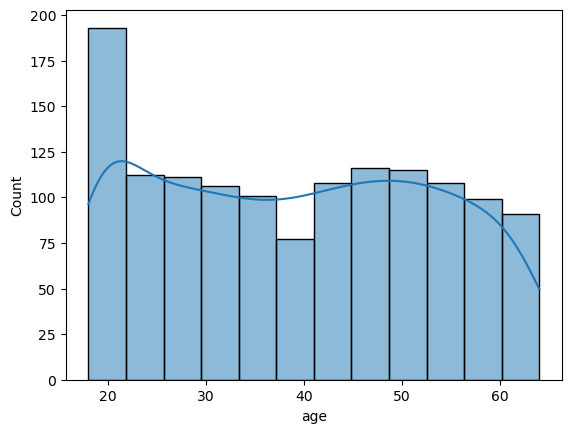

In [51]:
sns.histplot(x='age',data=df,kde=True)

In [12]:
df['age'].describe()

count    1337.000000
mean       39.222139
std        14.044333
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

### **Summary**

#### The `age` feature shows that the dataset includes 1337 individuals with ages ranging from 18 to 64 years. The average age is around 39 years, indicating a balanced mix of young, middle-aged, and older adults.

### **Key Insights**

#### • Most individuals fall between 27 to 51 years (middle 50% of data), showing a strong presence of working-age population.
#### • The median age (39) is very close to the mean, suggesting a fairly balanced distribution without extreme skewness.
#### • Since age ranges from young adults to seniors, it is likely to have a meaningful impact on insurance charges.
#### • Older individuals may contribute to higher medical costs, making age an important predictor in the analysis.


### **Sex**


<Axes: xlabel='sex', ylabel='count'>

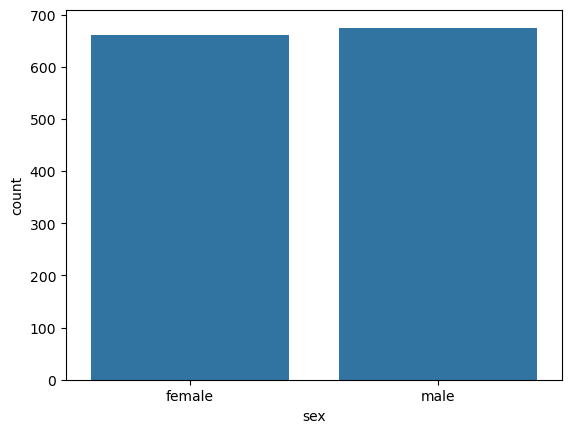

In [13]:
sns.countplot(x='sex',data=df)

In [14]:
df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

### **Summary**

#### The `sex` feature shows a nearly balanced distribution between male and female individuals in the dataset, with 675 males and 662 females.

### **Key Insights**

#### • The dataset is well-balanced in terms of gender representation, which reduces bias in analysis.
#### • Since the difference is very small, gender-based comparisons of insurance charges will be more reliable.
#### • This feature can help check whether medical insurance costs vary significantly between males and females.


### **BMI**

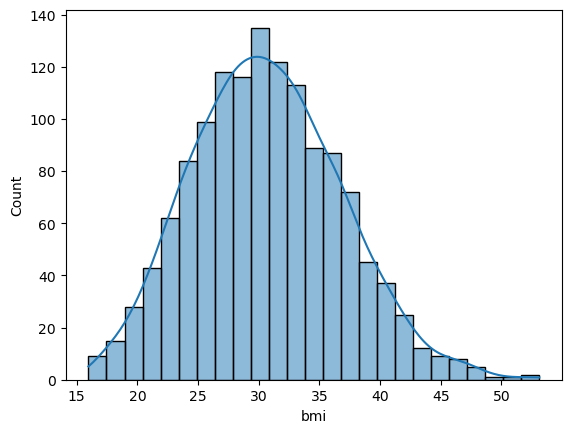

In [52]:
sns.histplot(x='bmi',data=df,kde=True)

In [16]:
df['bmi'].describe()

count    1337.000000
mean       30.663452
std         6.100468
min        15.960000
25%        26.290000
50%        30.400000
75%        34.700000
max        53.130000
Name: bmi, dtype: float64

### **Summary**

#### The `bmi` feature has 1337 observations with values ranging from 15.96 to 53.13. The average BMI is around 30.66, which is slightly above the normal range, indicating a tendency toward overweight individuals in the dataset.

### **Key Insights**
#### • The middle 50% of data lies between 26.29 and 34.70, showing many individuals fall in the overweight category.
#### • The median (30.4) is close to the mean, suggesting a fairly symmetric distribution with slight right skew.
#### • The maximum value (53.13) indicates the presence of extreme obesity cases, which may act as potential outliers.
#### • Since BMI is directly linked to health risks, it is expected to strongly influence insurance charges.


### **Children**

<Axes: xlabel='children', ylabel='Count'>

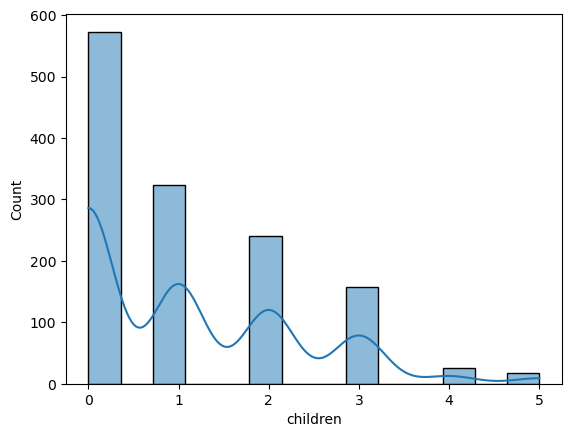

In [17]:
sns.histplot(x='children',data=df,kde=True)

In [18]:
df['children'].describe()

count    1337.000000
mean        1.095737
std         1.205571
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64

### **Summary**

#### The `children` feature represents the number of dependents covered in the insurance plan. It ranges from 0 to 5, with an average of about 1.1 children per individual.

### **Key Insights**

#### • A large portion of individuals have 0 to 2 children, as seen from the 25th and 75th percentile range (0 to 2).
#### • The median value is 1, indicating that most policyholders have a small family size.
#### • Very few cases have more than 3 children, making higher values relatively rare.
#### • Family size may influence insurance charges, as more dependents can increase overall healthcare costs.


### **Smoker**

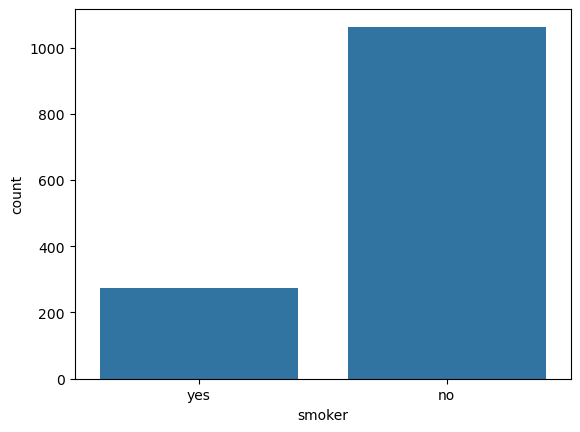

In [53]:
sns.countplot(x='smoker',data=df)

In [20]:
df['smoker'].describe()

count     1337
unique       2
top         no
freq      1063
Name: smoker, dtype: object

### **Summary**

#### The `smoker` feature is a binary categorical variable with two categories: “yes” and “no”. Most individuals in the dataset are non-smokers.

### **Key Insights**

#### • Around 1063 out of 1337 individuals are non-smokers, showing a strong dominance of the “no” category.
#### • Only a small portion of individuals are smokers, making this an imbalanced feature.
#### • Smoking is a critical health risk factor and is expected to significantly impact insurance charges.
#### • Due to its strong medical relevance, this feature may show a clear separation in cost patterns between smokers and non-smokers.


### **Region**

<Axes: xlabel='region', ylabel='count'>

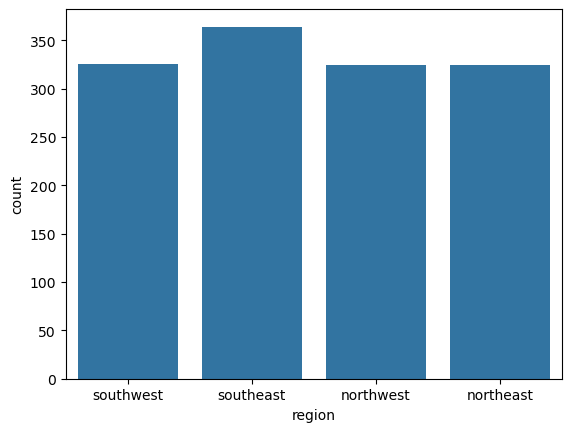

In [21]:
sns.countplot(x='region',data=df)

In [22]:
df['region'].describe()

count          1337
unique            4
top       southeast
freq            364
Name: region, dtype: object

### **Summary**

#### The `region` feature represents the geographical distribution of individuals across 4 regions, with a fairly balanced spread but one dominant region.

### **Key Insights**

#### • The dataset includes four regions, showing good geographical diversity.
#### • The southeast region is the most frequent (364 entries), indicating slightly higher representation from this area.
#### • Other regions are relatively evenly distributed, so no extreme imbalance is present.
#### • Region may influence insurance charges indirectly due to differences in lifestyle, environment, or healthcare access.


### **Charges**

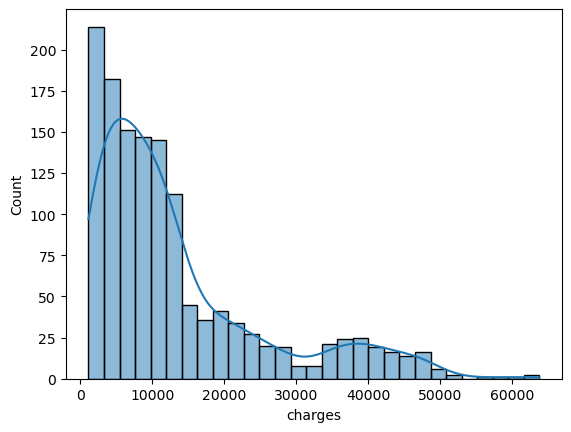

In [54]:
sns.histplot(x='charges',data=df,kde=True)

In [24]:
df['charges'].describe()

count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64

### **Summary**

#### The `charges` feature represents the medical insurance cost and shows a wide variation among individuals. Values range from 1121 to 63770, with an average cost of around 13279.

### **Key Insights**

#### • The large gap between minimum and maximum values indicates high variability in healthcare expenses.
#### • The median (9386) is significantly lower than the mean (13279), suggesting a right-skewed distribution.
#### • A small number of individuals have very high charges, pulling the average upward.
#### • This feature clearly shows that insurance cost is not uniform and is likely influenced by factors like age, BMI, and smoking status.


## **Final Univariate Insight**

#### Overall, the dataset shows a mix of balanced and skewed distributions. 
#### •Numerical features like age and BMI are fairly well spread, while charges show a strong right skew with few high-cost cases. 
#### •Categorical features such as sex and region are balanced, but smoker status is highly imbalanced, which is likely to be a key factor influencing insurance costs. 
#### •The data is clean and well-structured, making it suitable for further bivariate and multivariate analysis.

## **Bivariate Analysis**

#### The target variable for this analysis is **charges**,because charges is the outcome variable that represents the final insurance cost, and all other features (age, BMI, smoker, children, sex, region) influence it. So we study how different factors affect medical insurance cost.

### **Charges vs Age**

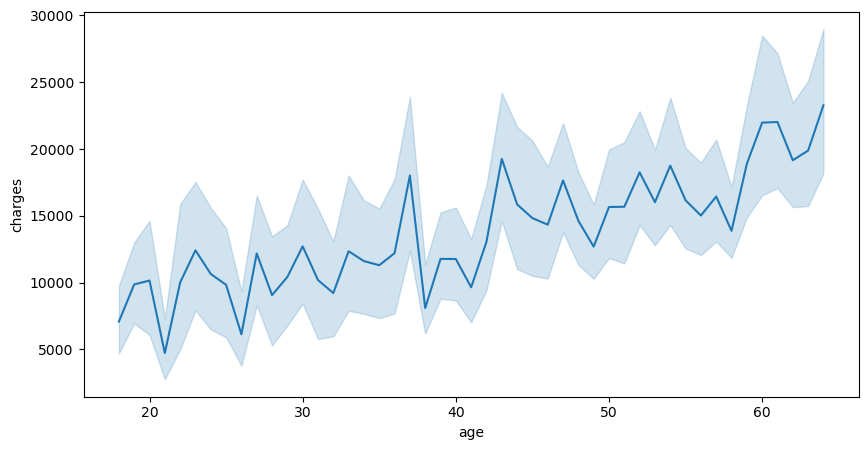

In [56]:
plt.figure(figsize=(10,5))
sns.lineplot(x='age', y='charges', data=df)

In [26]:
df[['age','charges']].corr()

,age,charges
age,1.000000,0.298308
charges,0.298308,1.000000


#### **Insight (Age vs Charges):**

#### Age and insurance charges show a **weak positive correlation (0.30)**. This means as age increases, medical insurance cost tends to increase slightly, but the relationship is not strong. 
#### In simple terms, older individuals generally pay higher charges, but age alone is not a strong deciding factor for insurance cost—other variables like smoking or BMI likely play a bigger role.


### **Charges vs Sex**

<Axes: xlabel='sex', ylabel='charges'>

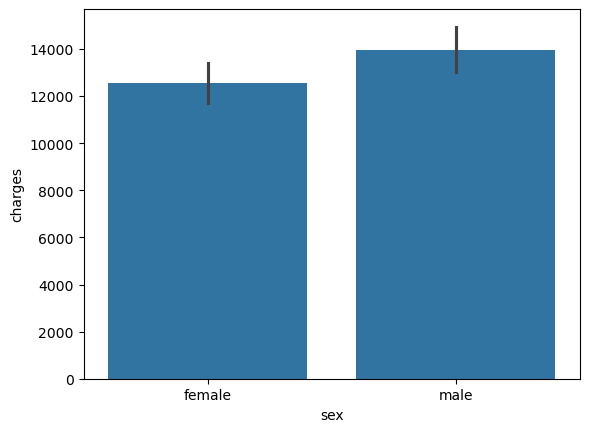

In [27]:
sns.barplot(x='sex',y='charges',data=df)

In [28]:
df.groupby('sex')['charges'].describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
female,662.0,12569.578844,11128.703801,1607.5101,4885.158700,9412.9625,14454.691825,63770.42801
male,675.0,13974.998864,12971.958663,1121.8739,4654.022675,9377.9047,19006.685500,62592.87309


#### **Insight (Sex vs Charges):**

#### Insurance charges are slightly higher for males compared to females. The average cost for males is around **13,975**, while for females it is about **12,570**, showing a small difference between the two groups. However, both groups show a wide spread in charges, indicating that gender alone does not strongly determine insurance cost. Other factors likely have a much bigger impact on pricing.


### **Charges vs BMI**

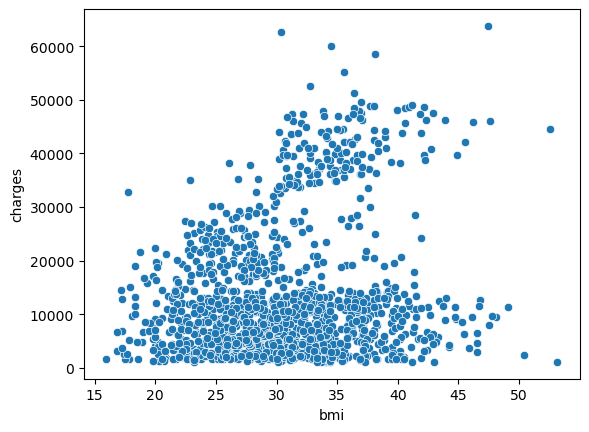

In [57]:
sns.scatterplot(x='bmi', y='charges', data=df)

In [30]:
df[['bmi','charges']].corr()

,bmi,charges
bmi,1.000000,0.198401
charges,0.198401,1.000000


#### **Insight (BMI vs Charges):**

#### BMI shows a **weak positive correlation (0.20)** with insurance charges. This suggests that as BMI increases, insurance cost tends to rise slightly, but the relationship is not strong. In simple terms, higher BMI may contribute to higher medical expenses, but it is not a major driver of charges on its own. Other factors like smoking status or age likely have a stronger influence on insurance cost.


### **Charges vs Children**

<Axes: xlabel='children', ylabel='charges'>

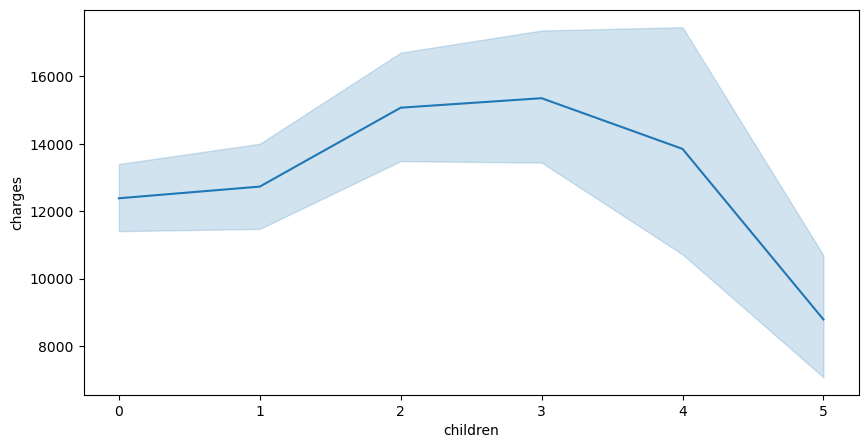

In [31]:
plt.figure(figsize=(10,5))
sns.lineplot(x='children', y='charges', data=df)

In [32]:
df[['children','charges']].corr()

,children,charges
children,1.000000,0.067389
charges,0.067389,1.000000


#### **Insight (Children vs Charges):**

#### Number of children has an **almost negligible positive correlation (0.07)** with insurance charges. This indicates that having more children does not meaningfully impact medical insurance cost. In simple terms, family size is not a significant factor in determining charges, and other variables like age, BMI, or smoking status play a much stronger role.


### **Charges vs Smoker**

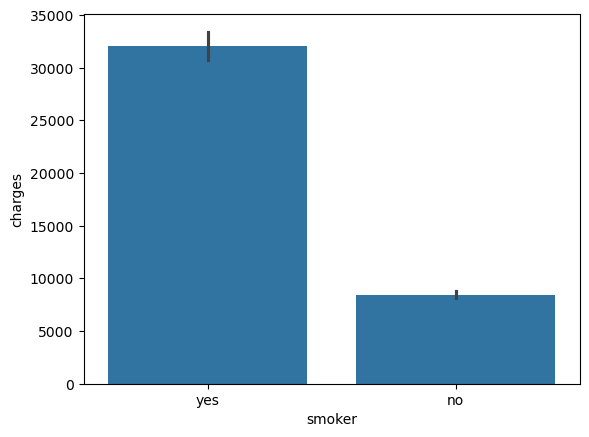

In [58]:
sns.barplot(x='smoker',y='charges',data=df)

In [34]:
df.groupby('smoker')['charges'].describe()

,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
no,1063.0,8440.660307,5992.973800,1121.8739,3988.883500,7345.72660,11363.019100,36910.60803
yes,274.0,32050.231832,11541.547176,12829.4551,20826.244213,34456.34845,41019.207275,63770.42801


#### **Insight (Smoker vs Charges):**

#### Smoking status has a **very strong impact on insurance charges**. Smokers have an average cost of around **32,050**, which is almost **4 times higher** than non-smokers at about **8,441**. Even the minimum charges for smokers are significantly higher than many non-smokers’ values. This clearly shows that smoking is one of the most influential factors driving up insurance costs, making it a major risk indicator in the dataset.


### **Charges vs Region**

<Axes: xlabel='region', ylabel='charges'>

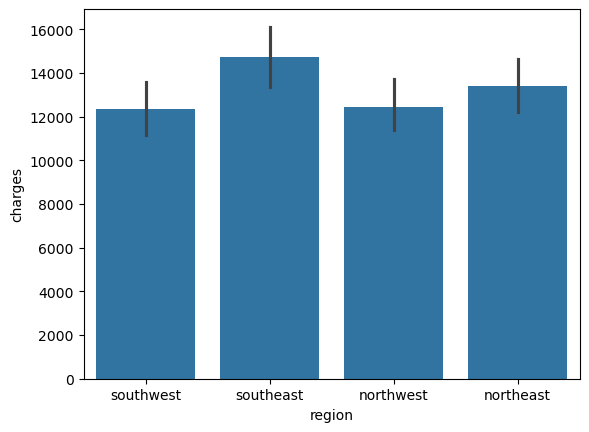

In [35]:
sns.barplot(x='region',y='charges',data=df)

In [36]:
df.groupby('region')['charges'].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
northeast,324.0,13406.384516,11255.803066,1694.7964,5194.322288,10057.652025,16687.364100,58571.07448
northwest,324.0,12450.840844,11073.125699,1621.3402,4733.635288,8976.977250,14788.747863,60021.39897
southeast,364.0,14735.411438,13971.098589,1121.8739,4440.886200,9294.131950,19526.286900,63770.42801
southwest,325.0,12346.937377,11557.179101,1241.5650,4751.070000,8798.593000,13462.520000,52590.82939


#### **Insight (Region vs Charges):**

#### Insurance charges show some variation across regions, but the difference is not very strong. The **southeast region has the highest average charges (~14,735)**, while the southwest has the lowest (~12,347). Other regions fall in a similar range, indicating only minor regional impact on insurance cost. Overall, location has a limited influence compared to major factors like smoking, BMI, or age.


#### **Final Conclusion (Bivariate Analysis) :**

#### From the bivariate analysis, it is clear that **insurance charges are not influenced equally by all features**. The most important factor is **smoking status**, which shows a very strong impact—smokers have significantly higher charges compared to non-smokers.

#### Other variables like **age and BMI show a weak positive relationship** with charges, indicating that costs increase slightly with higher age and body mass index, but the effect is not strong on its own.

#### Features such as **number of children, sex, and region have very little influence** on insurance charges, as their differences are small and not impactful compared to other variables.

#### Overall, the analysis suggests that **lifestyle-related factors (especially smoking) are the key drivers of medical insurance cost**, while demographic factors play a secondary or minimal role.


### **Hypothesis Evaluation**

#### **H1 (Age vs Charges)**

#### **Hypothesis:** Older individuals are expected to have higher medical charges due to increased health risks.

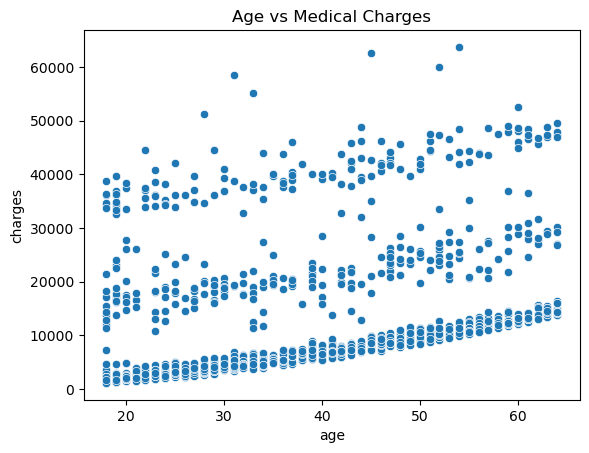

,age,charges
age,1.000000,0.298308
charges,0.298308,1.000000


In [59]:
sns.scatterplot(data=df, x='age', y='charges')
plt.title("Age vs Medical Charges")
plt.show()

df[['age','charges']].corr()


#### **Observation:**
#### • Charges show a gradual upward trend with age.
#### • The relationship is positive but not very strong.
#### • Older age groups generally have higher variability in charges.

#### **Conclusion:**
#### The analysis shows a mild to moderate positive relationship between age and medical charges. As age increases, healthcare costs tend to rise, likely due to higher medical needs in older individuals. However, the relationship is not extremely strong, suggesting other factors also play a major role.
#### **H1 is supported by the data.**

### **H2 (Smoking vs Charges)**
#### **Hypothesis:** Smokers have significantly higher medical charges compared to non-smokers.

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

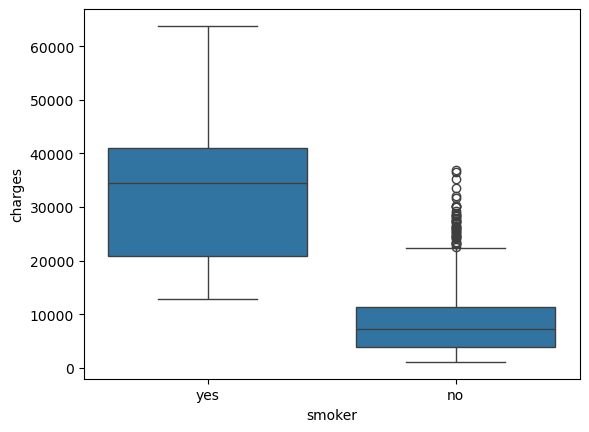

In [60]:
sns.boxplot(data=df, x='smoker', y='charges')

df.groupby('smoker')['charges'].mean()

#### **Observation:**
#### • Smokers have dramatically higher charges than non-smokers.
#### • Clear separation between the two groups is visible.
#### • Difference is large and consistent.

#### **Conclusion:** The analysis shows a strong and clear difference between smokers and non-smokers. Smokers incur significantly higher medical charges, indicating a strong association between smoking behavior and increased healthcare costs.
#### **H2 is strongly supported by the data.**

### **H3 (BMI vs Charges)**
#### **Hypothesis:** Higher BMI leads to higher healthcare expenses due to obesity-related health risks.

,bmi,charges
bmi,1.000000,0.198401
charges,0.198401,1.000000


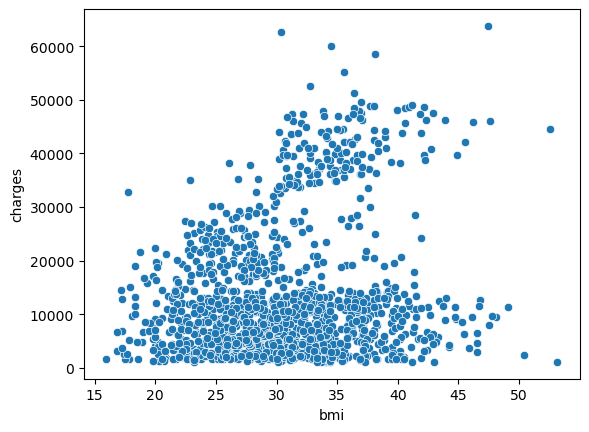

In [61]:
sns.scatterplot(data=df, x='bmi', y='charges')

df[['bmi','charges']].corr()

### **Observation:**
#### • Positive trend between BMI and charges is visible.
#### • Higher BMI values often correspond to higher charges.
#### • Relationship is moderate, not perfectly linear.

#### **Conclusion:** The analysis indicates a positive relationship between BMI and medical charges. Individuals with higher BMI tend to have increased healthcare costs, likely due to obesity-related health conditions.
#### **H3 is supported by the data.**

### **H4 (Children vs Charges)**
#### **Hypothesis:** Number of children slightly increases healthcare charges.

children
0    12384.695344
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64

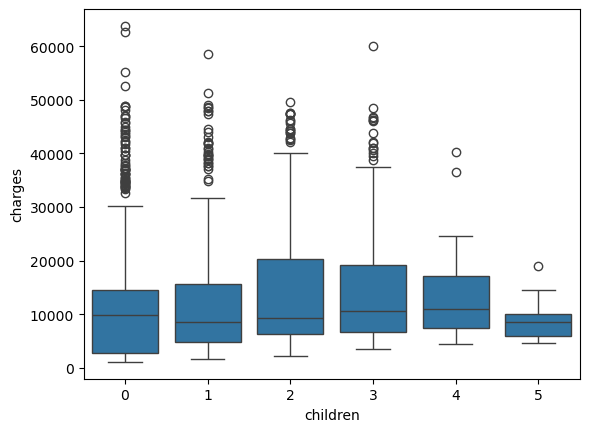

In [62]:
sns.boxplot(data=df, x='children', y='charges')

df.groupby('children')['charges'].mean()

#### **Observation:**
#### • Slight variation in charges across different child groups.
#### • No strong increasing trend is visible.
#### • Some fluctuations exist but no clear pattern.

#### **Conclusion:** The analysis shows a weak relationship between number of children and medical charges. While slight variations exist, there is no strong or consistent upward trend.
#### **H4 is partially supported.**

### **H5 (Region vs Charges)**
#### **Hypothesis:** Different regions show variation in healthcare charges due to cost of living and healthcare access.

region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

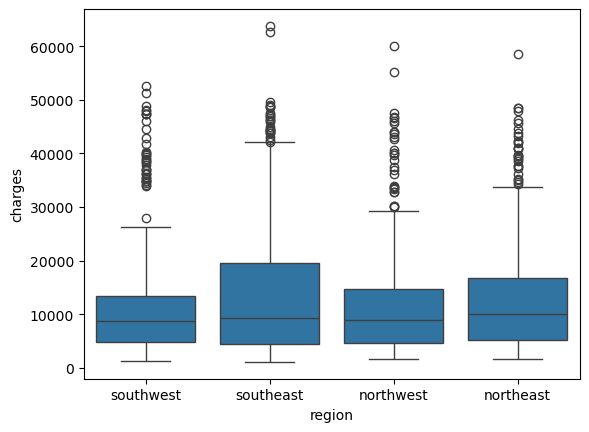

In [63]:
sns.boxplot(data=df, x='region', y='charges')

df.groupby('region')['charges'].mean()

#### **Observation:**
#### • All regions show similar charge distributions.
#### • Minor differences exist but no strong separation.
#### • No clear regional pattern is visible.

#### **Conclusion:** The analysis indicates that region has a minimal effect on medical charges. Differences between regions are small and not significant enough to suggest a strong relationship.
#### **H5 is weakly supported.**

### **H6 (Gender vs Charges)**
#### **Hypothesis:** Gender has little or no strong effect on healthcare charges.

sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64

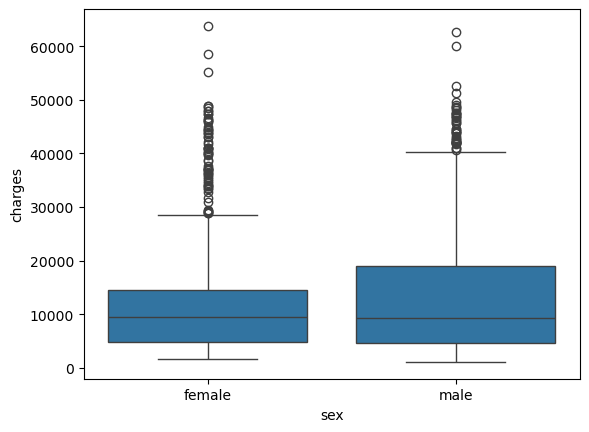

In [64]:
sns.boxplot(data=df, x='sex', y='charges')
plt.savefig(r'E:\EDA PROJECT\Healthcare Costs\Visualization\hypothesis\h6.png')

df.groupby('sex')['charges'].mean()

#### **Observation:**
#### • Male and female charge distributions are very similar.
#### • No major difference in averages.
#### • Slight variation exists but not meaningful.

#### **Conclusion:** The analysis shows that gender has minimal impact on healthcare charges. Both males and females exhibit similar cost distributions, indicating gender is not a strong predictor of insurance charges.
#### **H6 is supported by the data.**

### **Final Hypothesis Conclusion**

#### The hypothesis evaluation shows that most of the assumptions related to lifestyle factors are supported by the data, especially **smoking, BMI, and age** which show **strong to moderate relationships** with medical charges. However, some hypotheses such as **gender, region, and number of children** are **not** strongly supported and show weak or minimal impact on charges.


### **Multivariate Analysis**

### **Correlation Heatmap**

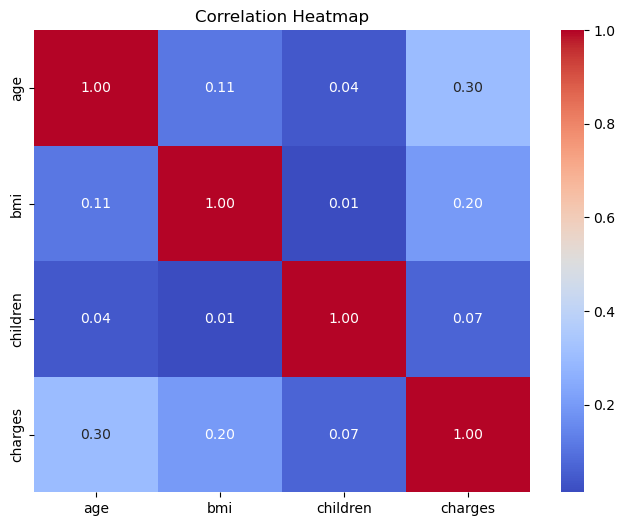

In [65]:
# Select numerical columns
num_cols = ['age', 'bmi', 'children', 'charges']

# Correlation matrix
corr_matrix = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [44]:
df[['age','bmi','children','charges']].corr()

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


#### **Correlation Insight**

#### • The correlation analysis indicates that **age has the strongest positive relationship with insurance charges** among all numerical variables, suggesting that healthcare costs tend to rise with increasing age.

#### • **BMI also shows a positive correlation with charges**, but the relationship is comparatively weaker. This means individuals with higher BMI may experience slightly higher medical expenses.

#### • The **number of children has a very weak correlation with charges**, indicating that family size does not strongly influence insurance costs in this dataset.

#### Overall, the correlations are low to moderate, showing that insurance charges are affected by multiple factors rather than a single variable alone.


### **Age vs BMI vs Charges**

,age,bmi,charges
age,1.000000,0.109344,0.298308
bmi,0.109344,1.000000,0.198401
charges,0.298308,0.198401,1.000000


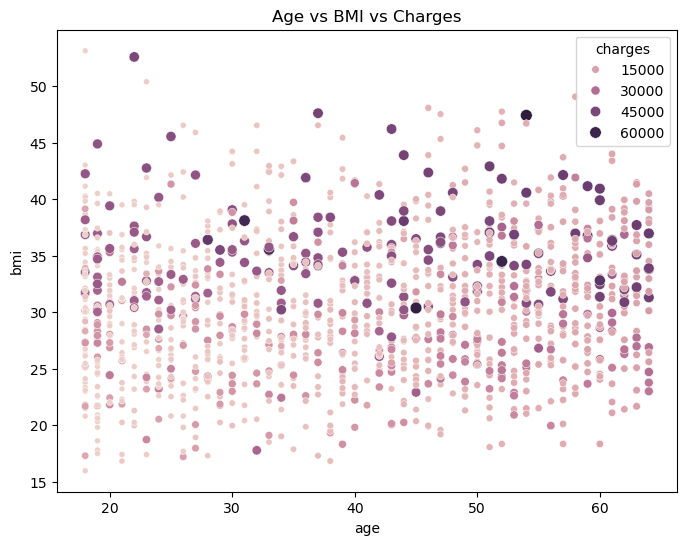

In [66]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='age',y='bmi',size='charges',hue='charges')
plt.title("Age vs BMI vs Charges")

df[['age','bmi','charges']].corr()


#### **Insight: Age, BMI, and Insurance Charges**

#### • The correlation analysis shows that **age has a moderate positive relationship with insurance charges**, meaning medical costs tend to increase as people get older.

#### • **BMI also shows a positive correlation with charges**, but the relationship is weaker compared to age. This suggests that higher body mass index may contribute to increased healthcare expenses.

#### • Additionally, the correlation between **age and BMI is very low**, indicating that both variables independently influence insurance charges.


### **Age vs Smoker vs Charges**

,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
no,1063.0,8440.660307,5992.973800,1121.8739,3988.883500,7345.72660,11363.019100,36910.60803
yes,274.0,32050.231832,11541.547176,12829.4551,20826.244213,34456.34845,41019.207275,63770.42801


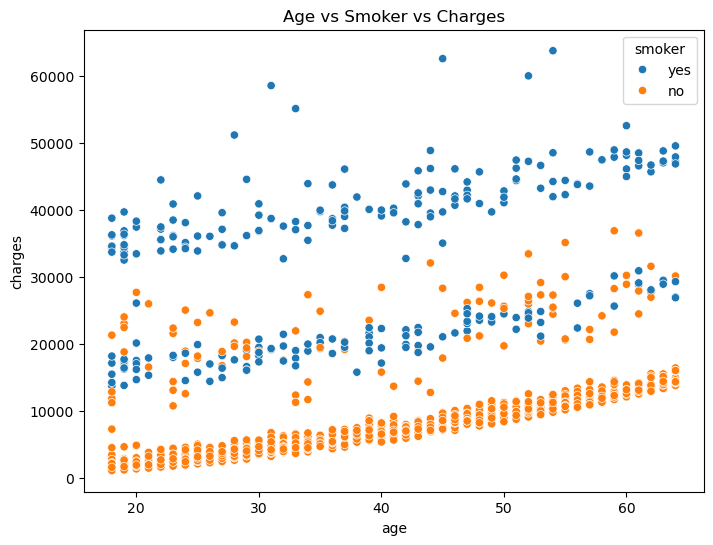

In [67]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='age',y='charges',hue='smoker')
plt.title("Age vs Smoker vs Charges")

df.groupby('smoker')['charges'].describe()


#### **Insight: Smoking Status vs Insurance Charges**

#### The analysis shows a significant difference in medical insurance charges between smokers and non-smokers.

#### People who smoke have a much higher average insurance cost compared to non-smokers. The average charges for smokers are nearly **four times** greater, indicating that smoking strongly impacts healthcare expenses.

#### Additionally, smokers also show a wider variation in charges, suggesting higher medical risk and treatment costs within this group.


### **BMI vs Smoker vs Charges**

,bmi,charges
smoker,,
no,30.651853,8440.660307
yes,30.708449,32050.231832


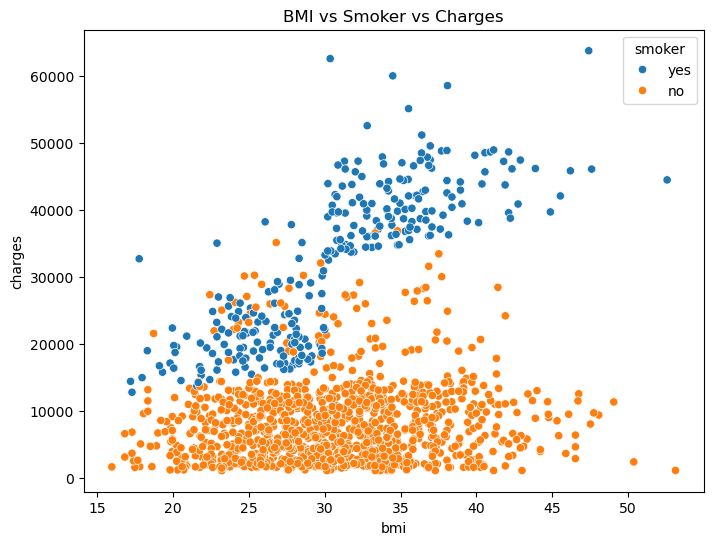

In [68]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='bmi',y='charges',hue='smoker')
plt.title("BMI vs Smoker vs Charges")

df.groupby('smoker')[['bmi','charges']].mean()

#### **Insight: BMI, Smoking, and Insurance Charges**

#### The average BMI of smokers and non-smokers is almost the same, showing that body mass index alone does not explain the large difference in insurance costs.

#### However, insurance charges for smokers are extremely higher despite having a similar BMI range. This indicates that smoking has a much stronger impact on healthcare expenses than BMI in this dataset.


### **Age vs BMI vs Smoker vs Charges**

,age,bmi,charges
smoker,,,
no,39.404516,30.651853,8440.660307
yes,38.514599,30.708449,32050.231832


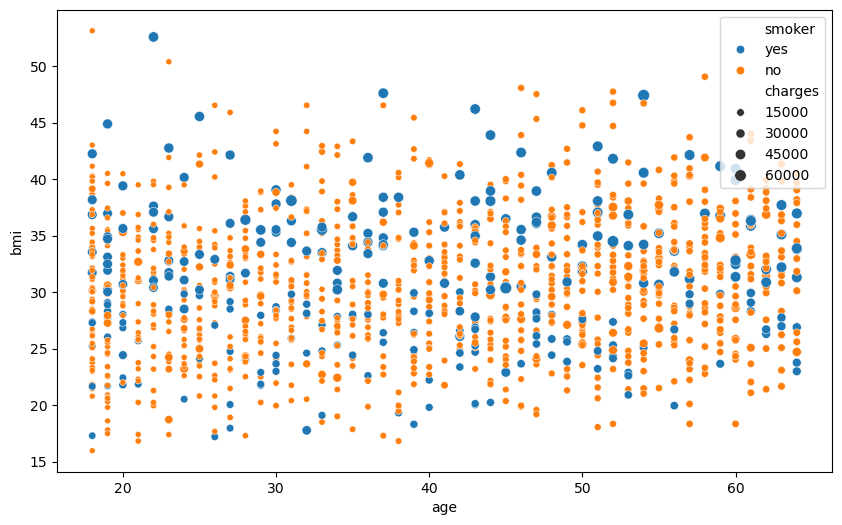

In [73]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='age',y='bmi',hue='smoker',size='charges')

df.groupby('smoker')[['age','bmi','charges']].mean()


#### **Insight: Age, BMI, Smoking, and Insurance Charges**

#### The average age and BMI of smokers and non-smokers are nearly similar, indicating that both groups have comparable demographic and body composition patterns.

#### Despite these similarities, smokers have significantly higher insurance charges than non-smokers. This suggests that smoking is a major factor influencing medical costs, even when age and BMI remain almost the same.


### **Pairplot**

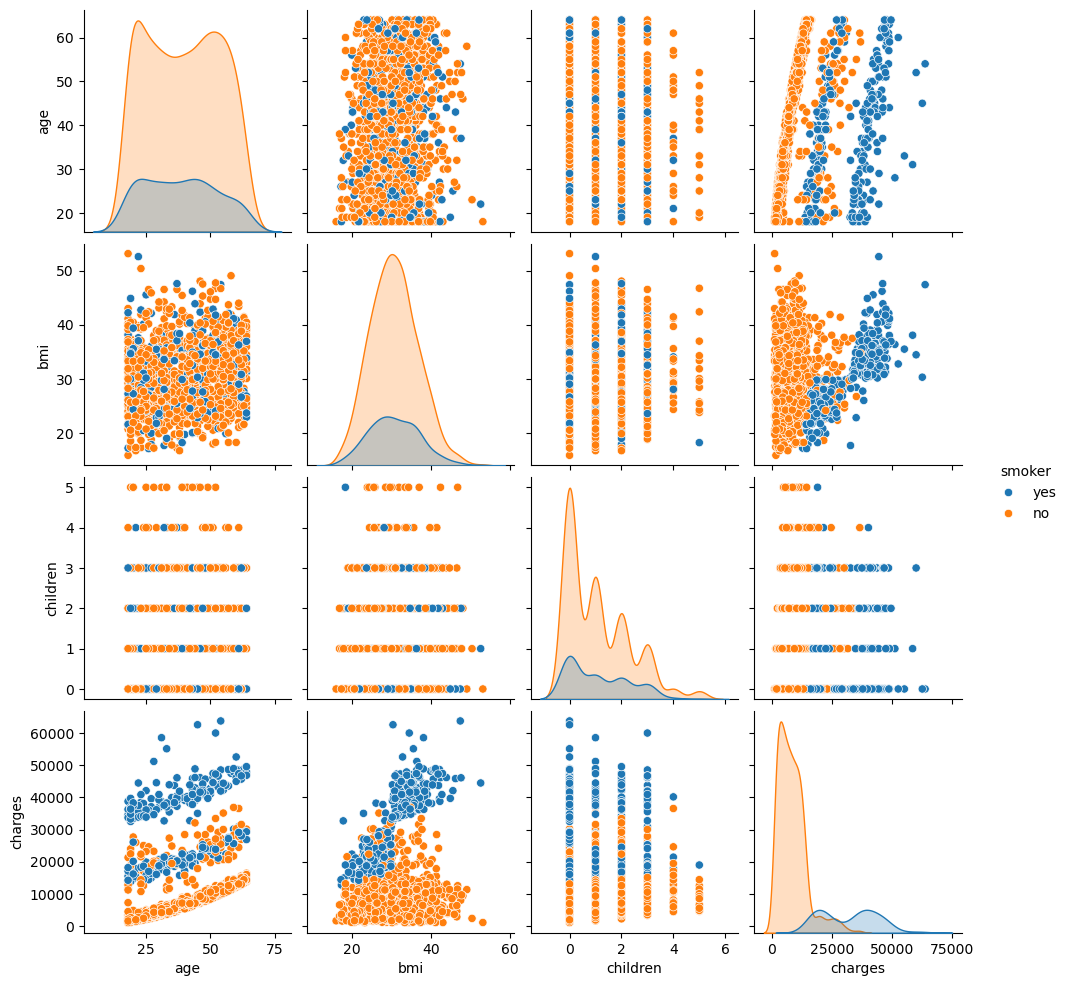

In [74]:
sns.pairplot(df,vars=['age', 'bmi', 'children', 'charges'],hue='smoker')

plt.show()

#### **Pairplot Insight**

#### The pairplot reveals clear relationships between age, BMI, smoking status, and insurance charges. A distinct cluster of smokers can be observed with significantly higher medical charges compared to non-smokers.

#### Insurance costs generally increase with age and BMI, especially among smokers. Non-smokers mostly show lower and more consistent charges, while smokers display greater variation and several high-cost outliers.

#### Overall, the visualization highlights smoking as the most influential factor affecting insurance expenses in the dataset.


### **Interaction Analysis (Age + BMI + Smoker → Charges)**

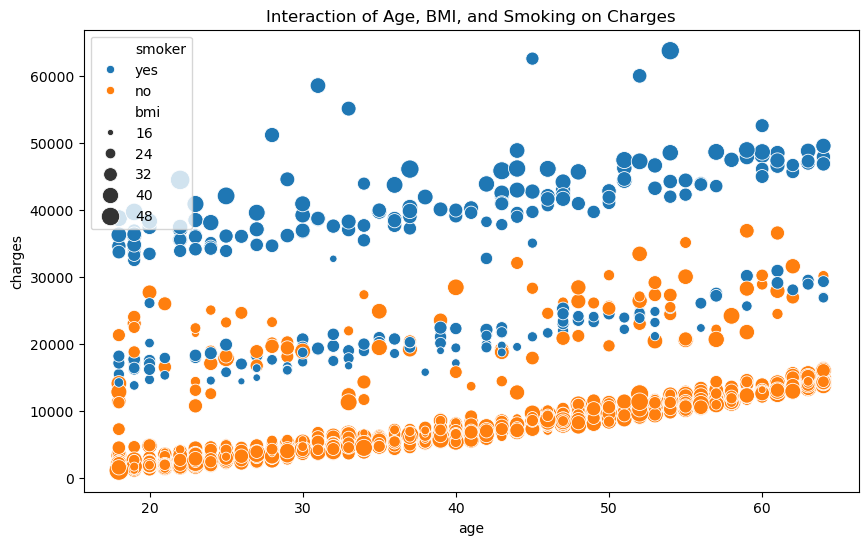

In [75]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='age',y='charges',hue='smoker',size='bmi',sizes=(20, 200))
plt.title('Interaction of Age, BMI, and Smoking on Charges')

plt.show()

### **Interaction Analysis Insight**

#### The interaction plot shows that insurance charges are not influenced by a single factor but by the combination of age, BMI, and smoking status.

#### Smokers consistently show higher charges across all age groups, and this effect becomes more pronounced with increasing age and BMI. Individuals with higher BMI and smoking habits tend to fall into the highest cost segment.

#### Overall, smoking acts as a strong amplifying factor, increasing the impact of both age and BMI on healthcare expenses.


### **Multivariate Analysis Conclusion**

#### The multivariate analysis reveals that insurance charges are influenced by the combined effect of multiple factors such as age, BMI, and smoking status. Among all variables, smoking emerged as the most significant factor associated with higher medical expenses.

#### Age and BMI also show a positive relationship with charges, indicating that healthcare costs tend to increase with growing age and higher body mass index. However, the number of children has only a minimal impact on insurance costs.

#### The interaction analysis further highlights that individuals who are older, have higher BMI, and smoke tend to incur the highest insurance charges. Overall, the analysis demonstrates that healthcare expenses are driven by the interaction of several risk factors rather than a single variable alone.


### **Final Overall Conclusion**

#### The exploratory data analysis of the healthcare insurance dataset identified several important factors influencing medical insurance charges. The analysis showed that smoking status has the strongest impact on insurance costs, with smokers paying significantly higher charges than non-smokers.

#### Age and BMI also demonstrate a positive relationship with insurance expenses, indicating that older individuals and people with higher body mass index tend to incur higher healthcare costs. In contrast, the number of children shows only a weak influence on charges.

#### The multivariate analysis further revealed that the combination of smoking, increasing age, and higher BMI leads to the highest insurance charges. Overall, the study highlights that healthcare expenses are affected by multiple interacting factors rather than a single variable

### **Recommendations**

#### • Promote awareness about the health and financial risks associated with smoking.

#### • Encourage healthy lifestyle habits to help maintain a balanced BMI and reduce medical expenses.

#### • Insurance companies can design personalized premium plans based on risk factors such as smoking status, age, and BMI.

#### • Regular health checkups and preventive care may help reduce long-term healthcare costs.

#### • High-risk individuals should be targeted for wellness and health improvement programs.

### **Business Insights**

#### • Smoking is the strongest factor increasing insurance charges, making smokers a high-risk customer segment for insurance companies.

#### • Customers with higher BMI and older age tend to generate higher medical expenses, indicating increased healthcare risk.

#### • Insurance providers can use age, BMI, and smoking status to design more accurate and personalized premium plans.

#### • Preventive healthcare and wellness programs may help reduce long-term insurance costs and claim amounts.

#### • Identifying high-risk groups early can help insurance companies improve risk management and customer health strategies.
